In [12]:
# from sklearn.model_selection import GridSearchCV
# from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc
# from sklearn import svm
# from sklearn.ensemble import RandomForestClassifier
# from src.processing import Processing
import config
# from sklearn.feature_selection import SelectKBest, chi2
# import matplotlib.pyplot as plt
# import seaborn as sns
# import joblib
# import pandas as pd
# import numpy as np
# from imblearn.over_sampling import SMOTE
# from imblearn.under_sampling import RandomUnderSampler
import warnings
import random
# from src.datasplitting import DataSplitting
warnings.filterwarnings('ignore')
# from sklearn.model_selection import GridSearchCV, PredefinedSplit, TimeSeriesSplit
# # from sklearn.metrics import (
# #     accuracy_score, f1_score, precision_score, recall_score,
# #     confusion_matrix, roc_auc_score, precision_recall_curve, auc, classification_report
# )
# from src.processing import Processing
# from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score
# from sklearn.decomposition import PCA
# from sklearn.neighbors import KNeighborsClassifier
# from imblearn.under_sampling import EditedNearestNeighbours
# from imblearn.pipeline import make_pipeline, Pipeline
# from sklearn.preprocessing import StandardScaler
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
import os
# from imblearn.over_sampling import SMOTE
# from collections import Counter
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
import os
import gc
from tfrecordimagehandler import TFRecordImageHandler
from tfrecordmultimodalhandler import TFRecordMultimodalHandler
from tfrecordhandler import TFRecordDataHandler

# from tfrecordhandler import TFRecordDataHandler
# from src.datasplitting_for_images import DataSplittingForImages

In [13]:
import matplotlib.pyplot as plt
import numpy as np
def visualize_data(image_batch, mask_batch, num_samples=4):
    plt.figure(figsize=(10, num_samples * 2))
    for i in range(num_samples):
        # Imagen en escala de grises
        plt.subplot(num_samples, 2, 2 * i + 1)
        plt.imshow(np.squeeze(image_batch[i]), cmap='gray')
        plt.title(f"Image {i}")
        plt.axis('off')

        # Máscara correspondiente
        plt.subplot(num_samples, 2, 2 * i + 2)
        plt.imshow(np.squeeze(mask_batch[i]), cmap='gray')
        plt.title(f"Mask {i}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()


In [14]:
# Definir hiperparámetros
INPUT_DIR = 'input/deep_learning'
batch_size = 32
n_epochs = 10
checkpoint = './best_model_vgg.h5'
shuffle = True
verbose = 1

In [15]:
# def _bytes_feature(value):
#     """Returns a bytes_list from a string / byte."""
#     return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))

# def _int64_feature(value):
#     """Returns an int64_list from a bool / enum / int / uint."""
#     return tf.train.Feature(int64_list=tf.train.Int64List(value=[value]))

# def serialize_example(image_path, mask_path):
#     img = tf.io.decode_image(tf.io.read_file(image_path), channels=3)
#     img_bytes = img.numpy().tobytes()

#     mask = tf.io.decode_image(tf.io.read_file(mask_path), channels=1)
#     mask_bytes = mask.numpy().tobytes()

#     # Get Study, Mice group and Day of study from the path
#     path = os.path.normpath(mask_path)
    
#     # Divide el path en partes
#     path_parts = path.split(os.sep)

#     # Extraer las partes relevantes
#     # 0 for Cured Mice, 1 for Relapsing Mice, 2 for Control Mice
#     if path_parts[2] == 'Cured mice':
#         group_name = 1
#     elif path_parts[2] == 'IMS-TMS-TREATED-RELAPSING':
#         group_name = 0
#     elif path_parts[2] == 'Control':
#         group_name = 0
#     else:
#         print(path_parts)
#         raise ValueError('Invalid group')
#     mouse_id = path_parts[3]       # 'C1281'
#     day_of_study = path_parts[4]   # 'day10'

#     # Get only the integers in ids
#     mouse_id = mouse_id[1:]
#     day_of_study = day_of_study[3:]

#     feature = {
#         'image': _bytes_feature(img_bytes),
#         'mask': _bytes_feature(mask_bytes),
#         'height': _int64_feature(img.shape[0]),
#         'width': _int64_feature(img.shape[1]),
#         'mask_height': _int64_feature(mask.shape[0]),
#         'mask_width': _int64_feature(mask.shape[1]),
#         'group_name': _int64_feature(int(group_name)),
#         'mouse_id': _int64_feature(int(mouse_id)),
#         'day_of_study': _int64_feature(int(day_of_study))
#     }
    
#     return tf.train.Example(features=tf.train.Features(feature=feature)).SerializeToString()

# def create_tfrecord(file_paths, output_file):
#     with tf.io.TFRecordWriter(output_file) as writer:
#         for img_path, mask_path in file_paths:
#             # print(f"Writing {img_path} and {mask_path} to {output_file}")
            
#             if not os.path.exists(img_path) or not os.path.exists(mask_path):
#                 print(f'Image or mask not found: {img_path}, {mask_path}')
#                 continue

#             try:
#                 example = serialize_example(img_path, mask_path)
#                 writer.write(example)
#             except Exception as e:
#                 print(f"Error serializing {img_path}, {mask_path}: {e}")

# def split_dataset_by_m_id(root_dir, train_ratio=0.8):
#     mouse_to_data = {}
    
#     # Recorrer todas las imágenes y máscaras
#     for data_group in os.listdir(root_dir):
#         data_group_path = os.path.join(root_dir, data_group)
#         if not os.path.isdir(data_group_path):
#             continue
#         for mice_group in os.listdir(data_group_path):
#             mice_group_path = os.path.join(data_group_path, mice_group)
#             if not os.path.isdir(mice_group_path):
#                 continue  # Saltar si no es un directorio
#             for dayofstudy in os.listdir(mice_group_path):
#                 dayofstudy_path = os.path.join(mice_group_path, dayofstudy)
#                 if not os.path.isdir(dayofstudy_path):
#                     continue  # Saltar si no es un directorio
#                 mri_imgs = os.path.join(dayofstudy_path, 'MRI images')
#                 if not os.path.exists(mri_imgs):
#                     print(f"No se encontró la carpeta {mri_imgs}")
#                     continue
#                 # Número de imágenes
#                 n_imgs = len(os.listdir(mri_imgs))
#                 for i in range(n_imgs):
#                     img_path = os.path.join(mri_imgs, f'image_s{i + 1}.jpg')
#                     mask_path = os.path.join(dayofstudy_path, f'Mask s{i + 1}.jpg')
                    
#                     # Get Study, Mice group and Day of study from the path
#                     path = os.path.normpath(mask_path)
                    
#                     # Divide el path en partes
#                     path_parts = path.split(os.sep)

#                     # Extraer las partes relevantes
#                     # 0 for Relapsing Mice, 1 for Cured Mice, 2 for Control Mice
#                     if path_parts[2] == 'Cured mice':
#                         group_name = 1
#                     elif path_parts[2] == 'IMS-TMS-TREATED-RELAPSING':
#                         group_name = 0
#                     elif path_parts[2] == 'Control':
#                         group_name = 2
#                     else:
#                         raise ValueError('Invalid group')
                    
#                     mouse_id = path_parts[3]       # 'C1281'
#                     day_of_study = path_parts[4]   # 'day10'

#                     # Get only the integers in ids
#                     mouse_id = mouse_id[1:]  # Remove 'C'
#                     day_of_study = day_of_study[3:]  # Remove 'day'
                    
#                     # Append data to mouse ID group
#                     if mouse_id not in mouse_to_data and group_name != 2:
#                         mouse_to_data[mouse_id] = []
#                     if group_name != 2:
#                         mouse_to_data[mouse_id].append((img_path, mask_path, group_name, mouse_id, day_of_study))

#     print(mouse_to_data)

#     test_ids = ['1276', '1281', '1263', '1264'] # Two cured and two relapsing mice
#     # train_ids = ['1284', '1285', '1382', '1270', '1380', '1383', 'C1258', 'C1260', 'C1261', 'C1297', 'C1299', 'C1359', 'C1360', 'C1361'] # Three cured and three relapsing mice (1284, 1285, 1382), (1270, 1380, 1383)
#     train_ids = ['1284', '1285', '1382', '1270', '1380', '1383','1276', '1281', '1263', '1264']
#     print(f"Train IDs: {train_ids}")
#     print(f"Test IDs: {test_ids}")

#     train_mice = [mice for k, mice in mouse_to_data.items() if k in train_ids]
#     test_mice = [mice for k, mice in mouse_to_data.items() if k in test_ids]

#     print(f"Train mice: {train_mice}")
#     print(f"Test mice: {test_mice}")

#     # # If the train set doesn't have a cured mouse, move one from test
#     # # if not any(mouse_id in train_mice for mouse_id in cured_mice):
#     # #     train_mice.add(cured_mice[0])
#     # #     test_mice.remove(cured_mice[0])

#     # # # If the test set doesn't have a cured mouse, move one from train
#     # # if not any(mouse_id in test_mice for mouse_id in cured_mice):
#     # #     test_mice.add(cured_mice[0])
#     # #     train_mice.remove(cured_mice[0])

#     # # Check that both train and test sets have a cured mouse
#     # print(f'Train mice: {train_mice}')
#     # print(f'Test mice: {test_mice}')

#     # # Assign data to train and test sets
#     # train_data = [data for mouse_id in train_mice for data in mouse_to_data[mouse_id]]
#     # test_data = [data for mouse_id in test_mice for data in mouse_to_data[mouse_id]]

#     train_paths = [(img, mask) for mouse_data in train_mice for img, mask, *_ in mouse_data]
#     test_paths = [(img, mask) for mouse_data in test_mice for img, mask, *_ in mouse_data]

#     print(f"Train paths: {train_paths}")
#     print(f"Test paths: {test_paths}")
    
#     print(f"Total data: {len(train_paths) + len(test_paths)}")
#     print(f"Train data: {len(train_paths)}")
#     print(f"Test data: {len(test_paths)}")
    
#     return train_paths, test_paths


In [16]:
# train_data, test_data = split_dataset_by_m_id(config.DATASET_DIR, train_ratio=0.7)
# train_tfrefcord = os.path.join(INPUT_DIR, 'train_new.tfrecord')
# # test_tfrefcord = os.path.join(INPUT_DIR, 'test_split.tfrecord')

# create_tfrecord(train_data, train_tfrefcord)
# # create_tfrecord(test_data, test_tfrefcord)

In [17]:
# train_tfrefcord = os.path.join(INPUT_DIR, 'train_split.tfrecord')
# test_tfrefcord = os.path.join(INPUT_DIR, 'test_split.tfrecord')

# train_tfrefcord = "input/tfrecord_dataset/full_ds.tfrecord"
# train_tfrefcord = os.path.join(INPUT_DIR, 'train_new.tfrecord')
train_tfrefcord = os.path.join(INPUT_DIR, 'train_new.tfrecord')



Number of train samples: 298
Number of batches: 9
Images min: 0.0, max: 255.0


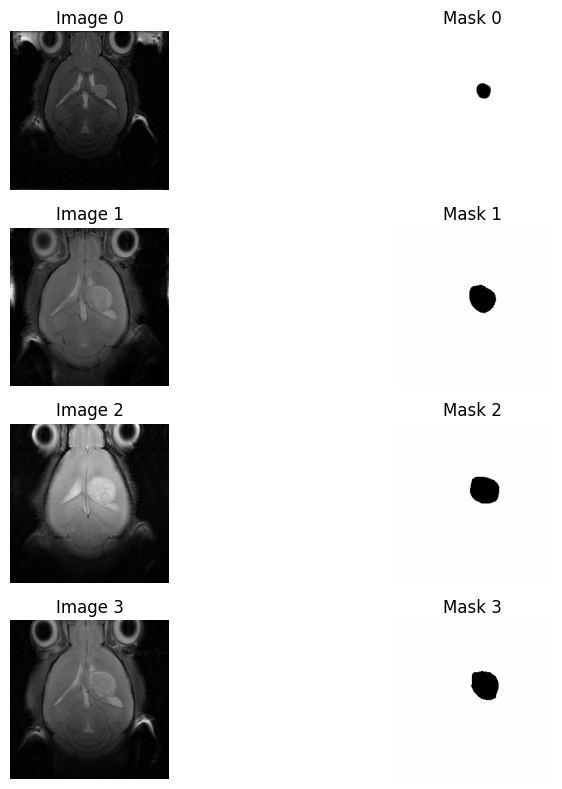

In [18]:
# train_ds_handler = TFRecordImageHandler(train_tfrefcord, batch_size=batch_size, shuffle=False, augment=False)
# train_ds_handler = TFRecordMultimodalHandler(train_tfrefcord, batch_size=batch_size, shuffle=False, augment=False)
train_ds_handler = TFRecordDataHandler(train_tfrefcord, batch_size=batch_size, shuffle=False, augment=False)
train_ds = train_ds_handler.dataset
print(f"Number of train samples: {train_ds_handler.length}")

# test_ds_handler = TFRecordImageHandler(test_tfrefcord, batch_size=batch_size, shuffle=False, augment=False)
# test_ds = test_ds_handler.dataset
# print(f"Number of test samples: {test_ds_handler.length}")

# Number of batches
n_batches = train_ds_handler.length // batch_size
print(f"Number of batches: {n_batches}")

images_tf, masks_tf, group_names, mouse_ids, days_of_study = next(iter(train_ds))

# Check if images are normalized
print(f"Images min: {images_tf.numpy().min()}, max: {images_tf.numpy().max()}")

visualize_data(images_tf, masks_tf, num_samples=4)
#visualize_data(images_tf, group_name_batches, num_samples=15)


In [19]:
SEED = 42
tf.random.set_seed(SEED)

# Oversampling with data augmentation
def augment_data(image, masks_tf, label, mouse_ids, days_of_study):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    return image, masks_tf, label, mouse_ids, days_of_study

def count_instances(dataset):
    total_count = 0
    for images, masks_tf, labels, mouse_ids, days_of_study in dataset:
        total_count += tf.size(labels)  # Count the number of labels (which equals the number of images in each batch)
    return total_count.numpy()  # Convert TensorFlow tensor to a regular integer

# def oversample_minority_class(dataset, minority_class=1, factor=2):
#     # Separate the minority and majority classes
#     minority_ds = dataset.filter(lambda img, lbl: tf.reduce_any(lbl == minority_class))
#     majority_ds = dataset.filter(lambda img, lbl: tf.reduce_any(lbl != minority_class))

#     # Count instances before augmentation
#     minority_count = count_instances(minority_ds)
#     majority_count = count_instances(majority_ds)

#     print(f"Before augmentation, Minority class size: {minority_count}, Majority class size: {majority_count}")
    
#     # Augment the minority class data
#     augmented_minority_ds = minority_ds.map(augment_data)
#     for _ in range(factor - 1):
#         augmented_minority_ds = augmented_minority_ds.concatenate(minority_ds.map(augment_data))

#     # Recombine and shuffle
#     balanced_ds = majority_ds.concatenate(augmented_minority_ds)
    
#     # After oversampling, count again
#     new_minority_count = count_instances(augmented_minority_ds)
#     new_majority_count = count_instances(majority_ds)
    
#     print(f"After augmentation, Minority class size: {new_minority_count}, Majority class size: {new_majority_count}")
    
#     return balanced_ds.shuffle(buffer_size=1000, seed=SEED)
def balance_minority_class_to_majority(dataset, minority_class=1):
    # Separate minority and majority datasets
    minority_ds = dataset.filter(lambda images_tf, masks_tf, lbl, mouse_ids, days_of_study : tf.reduce_any(lbl == minority_class))
    majority_ds = dataset.filter(lambda images_tf, masks_tf, lbl, mouse_ids, days_of_study : tf.reduce_any(lbl != minority_class))

    # Count original instances
    minority_count = count_instances(minority_ds)
    majority_count = count_instances(majority_ds)

    print(f"Before augmentation: Minority = {minority_count}, Majority = {majority_count}")

    # Calculate how many more samples we need to match the majority
    augment_times = (majority_count // minority_count) - 1
    remainder = majority_count % minority_count

    # Augment minority class to balance
    augmented_minority_ds = minority_ds
    for _ in range(augment_times):
        augmented_minority_ds = augmented_minority_ds.concatenate(minority_ds.map(augment_data))
    if remainder > 0:
        # Take a slice from the minority dataset, augment it and concatenate
        sampled_minority = minority_ds.take(remainder).map(augment_data)
        augmented_minority_ds = augmented_minority_ds.concatenate(sampled_minority)

    # Final rebalance and shuffle
    balanced_ds = majority_ds.concatenate(augmented_minority_ds).shuffle(buffer_size=1000, seed=SEED)

    # Check new counts
    new_minority_count = count_instances(augmented_minority_ds)
    new_majority_count = count_instances(majority_ds)
    print(f"After augmentation: Minority = {new_minority_count}, Majority = {new_majority_count}")

    return balanced_ds

# Apply oversampling to the dataset
# train_ds = oversample_minority_class(train_ds, minority_class=1, factor=2)
train_ds = balance_minority_class_to_majority(train_ds, minority_class=1)

Before augmentation: Minority = 96, Majority = 234
After augmentation: Minority = 288, Majority = 234


In [20]:
# # Print shape of images and masks
# print(f"Images shape: {images_tf.shape}")

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.metrics import F1Score, AUC, SensitivityAtSpecificity, SpecificityAtSensitivity, TruePositives, TrueNegatives, FalsePositives, FalseNegatives
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard
import cv2
import gc
import os
from datetime import datetime

# Define input_layer with the same shape that VGG16 expects
input_layer = tf.keras.layers.Input(shape=(256, 256, 3), name="input_layer")

# Load the pre-trained VGG16 model
base_model = VGG16(weights='imagenet', include_top=False, input_tensor=input_layer)

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Continue with custom layers
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

# Define the model
model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)

model.summary()

from sklearn.metrics import f1_score

# def f1_macro(y_true, y_pred):
#     # Convert the predicted probabilities to class labels (argmax operation along axis=1)
#     y_pred = tf.argmax(y_pred, axis=1)
    
#     # If y_true is sparse (integer labels), no need to apply tf.argmax, just use y_true as is
#     y_true = tf.cast(y_true, tf.int64)
    
#     # Convert tensors to numpy arrays before passing to f1_score
#     y_true = y_true.numpy()
#     y_pred = y_pred.numpy()
    
#     # Compute F1 score
#     return f1_score(y_true, y_pred, average='macro')

# # # Define directory paths for saving the model and TensorBoard logs
# # log_dir = os.path.join("logs", datetime.now().strftime("%Y%m%d-%H%M%S"))
# # model_save_path = "output/dl/{}/best_model.keras".format(datetime.now().strftime("%Y%m%d-%H%M%S"))

# # # Define callbacks
# # early_stopping = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
# # model_checkpoint = ModelCheckpoint(filepath=model_save_path, monitor='loss', save_best_only=False, verbose=1)
# # tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1, write_graph=True, write_images=True)

# # from tensorflow.keras import backend as K

# # def sensitivity(y_true, y_pred):
# #     y_pred = K.round(y_pred)
# #     tp = K.sum(K.cast(y_true * y_pred, 'float32'))
# #     fn = K.sum(K.cast(y_true * (1 - y_pred), 'float32'))
# #     return tp / (tp + fn + K.epsilon())

# # def specificity(y_true, y_pred):
# #     y_pred = K.round(y_pred)
# #     tn = K.sum(K.cast((1 - y_true) * (1 - y_pred), 'float32'))
# #     fp = K.sum(K.cast((1 - y_true) * y_pred, 'float32'))
# #     return tn / (tn + fp + K.epsilon())
# # def f1_score_custom(y_true, y_pred):
# #     y_pred = K.round(y_pred)
# #     tp = K.sum(K.cast(y_true * y_pred, 'float32'))
# #     fp = K.sum(K.cast((1 - y_true) * y_pred, 'float32'))
# #     fn = K.sum(K.cast(y_true * (1 - y_pred), 'float32'))
# #     precision = tp / (tp + fp + K.epsilon())
# #     recall = tp / (tp + fn + K.epsilon())
# #     return 2 * (precision * recall) / (precision + recall + K.epsilon())

# # metrics = [
# #     'accuracy',
# #     AUC(name='auc'),
# #     f1_score_custom,
# #     sensitivity,
# #     specificity,
# #     TruePositives(name='tp'),
# #     TrueNegatives(name='tn'),
# #     FalsePositives(name='fp'),
# #     FalseNegatives(name='fn')
# # ]
# # # Compile the model
# # model.compile(
# #     optimizer='adam',
# #     loss='binary_crossentropy',  # Change based on your label encoding
# #     metrics=metrics
# # )

# # # Train the model
# # history = model.fit(
# #     train_ds,
# #     #validation_data=test_ds,
# #     epochs=50,
# #     callbacks=[early_stopping, model_checkpoint, tensorboard_callback],
# #     verbose=1
# # )

# # Print model save location and TensorBoard log directory
# print(f"Best model saved to: {model_save_path}")
# print(f"TensorBoard logs available at: {log_dir}")

# To visualize TensorBoard logs, use the following command in your terminal:
# tensorboard --logdir=logs


import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split

from sklearn.model_selection import GroupKFold
import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np

# ⚙️ 1. Modelo extractor hasta LSTM
feature_extractor = models.Model(inputs=input_layer, outputs=x)  # x = salida LSTM

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score
import xgboost as xgb
import numpy as np

from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
import numpy as np
import xgboost as xgb
import tensorflow as tf

from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score
import numpy as np
import xgboost as xgb
import tensorflow as tf

# ✅ Extraer características y etiquetas, sin incluir los grupos
def extract_features_labels(dataset):
    features_list = []
    labels_list = []
    mouse_ids_list = []
    days_of_study_list = []

    for batch in dataset:
        x_batch, masks_tf, y_batch, mouse_ids, days_of_study = batch
        # Concatenate images and masks
        x_batch = tf.concat([x_batch, masks_tf, masks_tf], axis=-1)  # Concatenate along the last axis (channels)

        feats = feature_extractor.predict(x_batch)
        features_list.append(feats)
        labels_list.append(y_batch.numpy())
        mouse_ids_list.append(mouse_ids.numpy())
        days_of_study_list.append(days_of_study.numpy())

    X = np.concatenate(features_list, axis=0)
    y = np.concatenate(labels_list, axis=0)
    mouse_ids = np.concatenate(mouse_ids_list, axis=0)
    return X, y, mouse_ids

# 📌 Obtener características y etiquetas
X, y, mouse_ids = extract_features_labels(train_ds)

# 📌 Realizar Leave-One-Out Cross Validation (LOO-CV)
unique_mouse_ids = np.unique(mouse_ids)
all_y_true = []  # Lista para guardar todas las etiquetas verdaderas
all_y_pred = []  # Lista para guardar todas las predicciones
all_y_proba = []  # Lista para guardar las probabilidades predichas

# 📌 Métricas por fold
fold_accuracies = []
fold_aucs = []
fold_sensitivities = []
fold_specificities = []

# 📌 Iteración sobre cada mouse_id
for mouse_id in unique_mouse_ids:
    # Dividir en entrenamiento y prueba, basándonos en mouse_id
    train_indices = np.where(mouse_ids != mouse_id)[0]
    test_indices = np.where(mouse_ids == mouse_id)[0]

    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]

    # 📌 Entrenamiento con XGBoost
    xgb_clf = xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    )

    xgb_clf.fit(X_train, y_train)

    # 📌 Predicciones
    y_pred = xgb_clf.predict(X_test)
    y_proba = xgb_clf.predict_proba(X_test)[:, 1]

    # 📊 Métricas para este fold
    acc = accuracy_score(y_test, y_pred)
    # auc = roc_auc_score(y_test, y_proba)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    # Guardar las métricas de este fold
    fold_accuracies.append(acc)
    # fold_aucs.append(auc)
    fold_sensitivities.append(sensitivity)
    fold_specificities.append(specificity)

    # Guardar las predicciones y etiquetas verdaderas
    all_y_true.append(y_test)
    all_y_pred.append(y_pred)
    all_y_proba.append(y_proba)

    print(f"\nResultados para el mouse_id {mouse_id}:")
    print(f"✅ Accuracy: {acc:.4f}")
    # print(f"✅ AUC: {auc:.4f}")
    print(f"🔍 Sensitivity (Recall): {sensitivity:.4f}")
    print(f"🔍 Specificity: {specificity:.4f}")
    print(f"🟢 TP: {tp}, 🟡 FP: {fp}, 🔴 FN: {fn}, 🔵 TN: {tn}")

# 📊 Cálculos globales (después de todos los folds)
all_y_true = np.concatenate(all_y_true)
all_y_pred = np.concatenate(all_y_pred)
all_y_proba = np.concatenate(all_y_proba)

# Métricas globales
acc_global = accuracy_score(all_y_true, all_y_pred)
auc_global = roc_auc_score(all_y_true, all_y_proba)
tn, fp, fn, tp = confusion_matrix(all_y_true, all_y_pred).ravel()
sensitivity_global = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity_global = tn / (tn + fp) if (tn + fp) > 0 else 0

# Mostrar resultados globales
print("\n📈 Resultados Finales Globales:")
print(f"✅ Accuracy Global: {acc_global:.4f}")
print(f"✅ AUC Global: {auc_global:.4f}")
print(f"🔍 Sensitivity Global: {sensitivity_global:.4f}")
print(f"🔍 Specificity Global: {specificity_global:.4f}")
print(f"🟢 TP: {tp}, 🟡 FP: {fp}, 🔴 FN: {fn}, 🔵 TN: {tn}")

# 📊 Resultados por Fold
print("\n📈 Resultados por Fold:")
for i, mouse_id in enumerate(unique_mouse_ids):
    print(f"Mouse ID {mouse_id}:")
    print(f"    Accuracy: {fold_accuracies[i]:.4f}")
    # print(f"    AUC: {fold_aucs[i]:.4f}")
    print(f"    Sensitivity: {fold_sensitivities[i]:.4f}")
    print(f"    Specificity: {fold_specificities[i]:.4f}")



Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           25

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 132,097 (516.00 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 923ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 937ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 932ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 940ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 944ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 933ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 944ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 938ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 946ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 951ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 933ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 942ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 927ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 948ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 938ms/step

Resultados para el mouse_id 1263:
✅ Accuracy: 0.6986
🔍 Sensitivity (Recall): 0.0000
🔍 Specificity: 0.6986
🟢 TP: 0, 🟡 FP: 44, 🔴 FN: 0, 🔵 TN: 102

Resultados para el mouse_id 1264:
✅ Accuracy: 0.8605
🔍 Sensitivity (Recall): 0.0000
🔍 Specificity: 0.8605
🟢 TP: 0, 🟡 FP: 6, 🔴 FN: 0, 🔵 TN: 37

Resultados para el mouse_id 1270:
✅ Accuracy: 0.976

IndexError: list index out of range

In [ ]:
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate_model(model, dataset, dataset_name=""):
    y_true = []
    y_pred = []

    for images, labels in dataset:
        preds = model.predict(images)
        y_true.extend(labels.numpy().astype(int))
        y_pred.extend((preds > 0.5).astype(int).flatten())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    f1 = f1_score(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)

    print(f"\n--- Métricas en el conjunto de {dataset_name} ---")
    print(f'Accuracy: {acc:.4f}')
    print(f'F1 Score: {f1:.4f}')
    print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
    print(f'Specificity (TNR): {specificity:.4f}')
    print(f'PPV (Precision): {ppv:.4f}')
    print(f'NPV: {npv:.4f}')

    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=["Clase 0", "Clase 1"])
    plt.title(f"Matriz de confusión - {dataset_name}")
    plt.show()

# model = tf.keras.models.load_model(model, custom_objects={'f1_macro': f1_macro})
# Evaluar en test y train
# evaluate_model(model, test_ds, dataset_name="test")
evaluate_model(model, train_ds, dataset_name="train")


In [ ]:
model_save_path = "output/dl/best_model.keras"

model = tf.keras.models.load_model(model_save_path)

In [ ]:
for layer in model.layers:
    print(layer.name)

In [ ]:
from src.notebooks.dl.gradcam import GradCAM
import matplotlib.pyplot as plt
import numpy as np
import cv2

for image_batch, labels_batch in test_ds:
    batch_size = image_batch.shape[0]
    fig, axes = plt.subplots(5, batch_size, figsize=(3 * batch_size, 10))

    for i, (image, label) in enumerate(zip(image_batch, labels_batch)):
        image = image.numpy()  # Convertir tensor a NumPy array
        label = int(label.numpy())  # Asegurar que la etiqueta sea un entero

        # Imagen en escala de grises
        axes[0, i].imshow(np.squeeze(image[:, :, 0]), cmap='gray')
        axes[0, i].set_title(f"Image, label: {label}")
        axes[0, i].axis('off')

        # Máscara
        axes[1, i].imshow(np.squeeze(image[:, :, 1]), cmap='gray')
        axes[1, i].set_title("Mask")
        axes[1, i].axis('off')

        # GradCAM Heatmap
        gradcam = GradCAM(model, classIdx=label, layerName='block5_conv3')
        heatmap = gradcam.compute_heatmap(np.expand_dims(image, axis=0))
        axes[2, i].imshow(heatmap, cmap='jet')
        axes[2, i].set_title("GradCAM Heatmap")
        axes[2, i].axis('off')

        # GradCAM Overlay en imagen original
        grayscale_image = (image[:, :, 0] * 255).astype(np.uint8)  # Convertir a escala de grises uint8
        grayscale_image = cv2.cvtColor(grayscale_image, cv2.COLOR_GRAY2RGB)  # Convertir a RGB
        overlay = gradcam.overlay_heatmap(heatmap, grayscale_image)[1]
        axes[3, i].imshow(overlay)
        axes[3, i].set_title("GradCAM Overlay")
        axes[3, i].axis('off')

        # GradCAM Overlay en máscara
        mask_image = (image[:, :, 1] * 255).astype(np.uint8)  # Convertir máscara a uint8
        mask_image = cv2.cvtColor(mask_image, cv2.COLOR_GRAY2RGB)  # Convertir a RGB
        overlay_mask = gradcam.overlay_heatmap(heatmap, mask_image)[1]
        axes[4, i].imshow(overlay_mask)
        axes[4, i].set_title("GradCAM on Mask")
        axes[4, i].axis('off')
    
    plt.tight_layout()
    plt.show()



In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras import backend as K

# Function to get Grad-CAM heatmap
def get_gradcam_heatmap(model, img_array, class_index, layer_name="block5_conv3"):
    # Get the gradient of the class with respect to the last convolutional layer
    with tf.GradientTape() as tape:
        # The input image is the batch with shape (1, 256, 256, 3)
        last_conv_layer = model.get_layer(layer_name)
        tape.watch(last_conv_layer.output)
        preds = model(img_array)
        class_output = preds[:, class_index]
    
    # Get gradients of the predicted class with respect to the last conv layer
    grads = tape.gradient(class_output, last_conv_layer.output)
    
    # Pool the gradients across all the axes (height, width)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    # Multiply each channel in the feature map by the mean gradient
    last_conv_layer_output = last_conv_layer.output[0]
    for i in range(last_conv_layer_output.shape[-1]):
        last_conv_layer_output[:, :, i] *= pooled_grads[i]
    
    # Create the heatmap by averaging over all channels
    heatmap = tf.reduce_mean(last_conv_layer_output, axis=-1)
    
    # Normalize the heatmap
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)
    
    return heatmap

# Function to display Grad-CAM results
def display_gradcam(img, heatmap, alpha=0.4):
    # Resize heatmap to match the image dimensions
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    
    # Convert heatmap to RGB
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    
    # Overlay heatmap on the image
    superimposed_img = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)
    
    return superimposed_img

# Function to generate Grad-CAM for a sample from the test set
def gradcam_visualization(model, test_ds, n_images=3):
    # Pick some images from the test dataset
    test_images, test_labels = next(iter(test_ds))
    
    # Get class indices (assumes binary classification here)
    class_indices = np.argmax(test_labels, axis=1)
    
    # Plot results for the first few images
    for i in range(n_images):
        img = test_images[i].numpy().astype("uint8")  # Convert to numpy for display
        true_label = class_indices[i]
        
        # Get Grad-CAM heatmap
        heatmap = get_gradcam_heatmap(model, test_images[i:i+1], true_label)
        
        # Overlay Grad-CAM heatmap on the image
        superimposed_img = display_gradcam(img, heatmap)
        
        # Plot original image and Grad-CAM heatmap
        plt.figure(figsize=(12, 6))
        
        # Original Image
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.title(f"Original Image (True: {true_label})")
        plt.axis('off')
        
        # Image with Grad-CAM overlay
        plt.subplot(1, 2, 2)
        plt.imshow(superimposed_img)
        plt.title(f"Grad-CAM Overlay (True: {true_label})")
        plt.axis('off')
        
        plt.show()


